# 1.YOLO11_세그멘테이션

- 이번에는 같은 Ultralytics API를 사용하되 Detection이 아니라 Instance Segmentation을 수행한다.
- Object Detection은 객체 위치를 사각형 박스로 예측하고, Instance Segmentation은 객체별 픽셀 영역(mask)을 함께 예측한다.
- YOLO11 세그멘테이션 모델 이름은 `yolo11n-seg.pt`, `yolo11s-seg.pt`, `yolo11m-seg.pt`, `yolo11l-seg.pt`, `yolo11x-seg.pt` 형식을 사용한다.
- n 모델은 빠르고 가볍고, x 모델로 갈수록 무겁지만 정확도가 높아진다.



## 1.1.언제 세그멘테이션을 사용하는가?
- 객체의 위치만 알면 충분할 때는 Object Detection을 사용한다.
- 객체의 정확한 모양, 면적, 윤곽, 픽셀 영역이 필요할 때는 Segmentation을 사용한다.
- 예: 배경 제거, 객체만 합성, 자동 모자이크, 상품 누끼, 의료 영상 병변 영역 측정, 제조 결함 영역 측정, 자율주행 차선/사람/차량 영역 구분

## 1.2.참고 문서
- https://docs.ultralytics.com/tasks/segment/
- https://docs.ultralytics.com/modes/predict/
- https://docs.ultralytics.com/modes/train/

- 모델 학습에는 GPU 사용을 권장하므로 Google Colab에서 실습하는 것을 권장한다.
- 사전학습 모델 추론은 CPU에서도 실행 가능하지만 영상 추론과 학습은 시간이 오래 걸릴 수 있다.


In [1]:
# 필요한 패키지가 설치되어 있지 않을 때만 주석을 해제하고 실행합니다.
%pip install ultralytics opencv-python matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
from urllib.request import urlopen

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import ultralytics
from matplotlib import font_manager
from ultralytics import YOLO

print('torch 버전:', torch.__version__)
print('ultralytics 버전:', ultralytics.__version__)
print('CUDA 사용 가능 여부:', torch.cuda.is_available())

torch 버전: 2.8.0+cpu
ultralytics 버전: 8.4.51
CUDA 사용 가능 여부: False


# 2.사전학습 YOLO11 세그멘테이션 모델 사용하기

- `YOLO('yolo11n-seg.pt')`를 실행하면 MS COCO 데이터셋으로 사전학습된 세그멘테이션 모델을 불러온다.
- 처음 실행할 때 모델 파일이 없으면 Ultralytics가 자동으로 다운로드한다.
- `model.names`에는 COCO 80개 클래스 이름이 저장되어 있다.


In [3]:
# COCO 데이터셋으로 사전학습된 YOLO11 세그멘테이션 모델을 로드합니다.
seg_model = YOLO('yolo11n-seg.pt')

print('모델 작업:', seg_model.task)
print(type(seg_model.names), len(seg_model.names))
print(seg_model.names)

모델 작업: segment
<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboar

## 2.1.이미지 세그멘테이션 추론

- 세그멘테이션 모델을 사용하면 결과 객체 안에 `boxes`와 `masks`가 함께 저장된다.
- `save=True`를 주면 `runs/segment/predict` 아래에 결과 이미지가 저장된다.


In [4]:
# URL에서 이미지를 읽어오기 위한 함수
def load_image(source):
    # source가 pathlib.Path 같은 객체일 수도 있으므로 문자열로 변환합니다.
    source = str(source)

    # 이미지 경로가 http:// 또는 https://로 시작하면 인터넷에 있는 이미지라고 판단합니다.
    if source.startswith(('http://', 'https://')):
        # frombuffe: 읽어온 바이트 데이터를 OpenCV가 처리할 수 있는 numpy 배열로 변환합니다.
        data = np.frombuffer(urlopen(source).read(), np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    else:
        img = cv2.imread(source)

    if img is None:
        raise FileNotFoundError(f'이미지를 읽지 못했습니다: {source}')

    return img

# 이미지를 화면에 출력하는 함수입니다.
def show(img, title=''):
    # OpenCV 이미지를 Matplotlib에서 보이도록 색상 채널을 변환합니다.
    plt.figure(figsize=(9, 7))
    code = cv2.COLOR_BGRA2RGBA if img.shape[-1] == 4 else cv2.COLOR_BGR2RGB
    plt.imshow(cv2.cvtColor(img, code))
    plt.axis('off')
    plt.title(title)
    plt.show()

In [5]:
# 샘플 이미지 준비
img_path = 'https://ultralytics.com/images/bus.jpg'
img = load_image(img_path)

In [17]:
# 세그멘테이션 추론 실행: save=True이면 runs/segment 아래에 결과 저장
results = seg_model(img, save=True, conf=0.5)
result = results[0]

# 결과 출력
result.show()



0: 640x480 3 persons, 1 bus, 444.5ms
Speed: 62.8ms preprocess, 444.5ms inference, 32.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\playdata2\workspace\deep_learning\runs\segment\predict


## 2.2.결과 객체 구조 확인

- `result.masks.data`: 객체별 binary mask tensor를 저장한다.
- `result.masks.xy`: mask 외곽선을 polygon 좌표 목록으로 저장한다.


In [8]:
# result 객체에 저장된 원본 크기, 박스, 마스크 정보를 확인합니다.
print('원본 이미지 크기:', result.orig_shape)
print('마스크 텐서 크기:', result.masks.data.shape)
print('폴리곤 개수:', len(result.masks.xy))

원본 이미지 크기: (1080, 810)
마스크 텐서 크기: torch.Size([6, 640, 480])
폴리곤 개수: 6


In [14]:
for i, (cls_id, conf, polygon) in enumerate(zip(result.boxes.cls, result.boxes.conf, result.masks.xy)):
    cls_id = int(cls_id.item())
    conf = float(conf.item())
    class_name = seg_model.names[cls_id]
    print(f'{i:02d} | 클래스={class_name:12s} | 신뢰도={conf:.3f} | 폴리곤 좌표 수={len(polygon)}')

00 | 클래스=bus          | 신뢰도=0.899 | 폴리곤 좌표 수=691
01 | 클래스=person       | 신뢰도=0.885 | 폴리곤 좌표 수=235
02 | 클래스=person       | 신뢰도=0.863 | 폴리곤 좌표 수=327
03 | 클래스=person       | 신뢰도=0.822 | 폴리곤 좌표 수=197
04 | 클래스=stop sign    | 신뢰도=0.461 | 폴리곤 좌표 수=18
05 | 클래스=person       | 신뢰도=0.443 | 폴리곤 좌표 수=122


## 2.3.Mask를 직접 꺼내서 사용하기

- 세그멘테이션의 핵심 출력은 mask다.
- mask는 특정 객체가 차지하는 픽셀 위치를 0과 1에 가까운 값으로 표현한다.
- 아래 코드는 confidence가 가장 높은 객체 하나를 선택하고, 원본 이미지에서 해당 객체 영역만 분리한다.


In [9]:
# 원하는 객체 클래스 이름 지정. 예: person, bus, car, bicycle
TARGET = ['person']
h, w = img.shape[:2]

# 모델이 예측한 mask와 클래스 이름을 꺼냅니다.
masks = result.masks.data.cpu().numpy()
classes = [seg_model.names[int(i)] for i in result.boxes.cls.cpu()]
binary = [cv2.resize(m, (w, h)) > 0.5 for m in masks]

# TARGET 클래스가 여러 개면 하나의 mask로 합칩니다.
selected = [m for m, name in zip(binary, classes) if name in TARGET]
if selected:
    mask = np.any(selected, axis=0)
    print(f'선택 클래스: {TARGET}, 객체 수: {len(selected)}')
else:
    # TARGET이 없으면 confidence가 가장 높은 객체 하나를 대신 선택합니다.
    idx = int(result.boxes.conf.argmax().item())
    mask = binary[idx]
    print(f'{TARGET} 없음 -> 선택 클래스: {classes[idx]}')

선택 클래스: ['person'], 객체 수: 4


## 2.4.컬러팝 만들기
- 선택한 객체는 컬러로 남기고, 배경은 흑백으로 바꾼다.


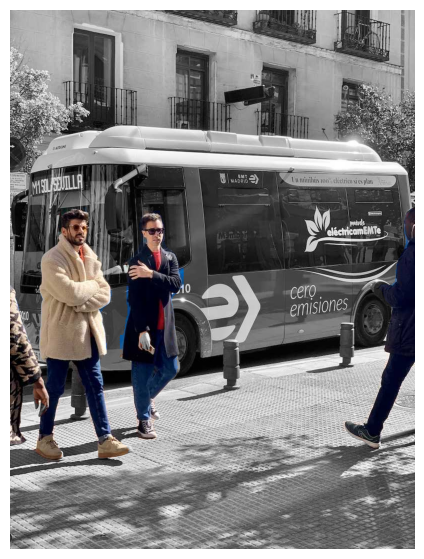

In [10]:
# 배경은 흑백으로 바꾸고 선택한 객체만 컬러로 유지합니다.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
colorpop = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
colorpop[mask] = img[mask]

show(colorpop)

## 2.5.투명 배경 스티커 만들기

- mask 영역만 남기고 나머지는 투명하게 만든다.
- 결과는 PNG 파일로 저장된다.


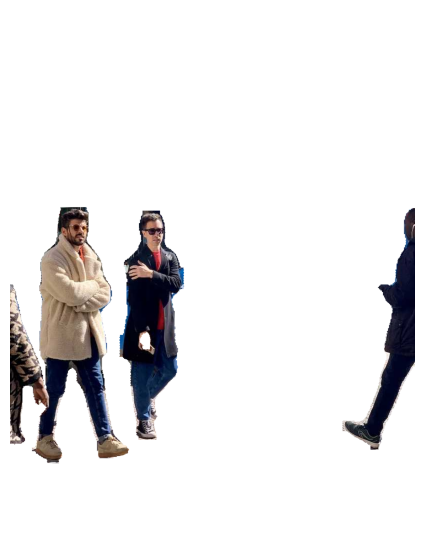

저장 완료: runs\segment_playground\['person']_sticker.png


In [11]:
# 선택한 객체 영역만 불투명하게 남긴 PNG 스티커를 만듭니다.
out_dir = Path('runs/segment_playground')
out_dir.mkdir(parents=True, exist_ok=True)

# sticker[:, :, 3] : 4번째 채널, 즉 Alpha 채널.
# 여기에 255를 곱하면 객체 영역은 255가 되어 완전 불투명해지고,
# 배경 영역은 0이 되어 완전 투명해짐.
sticker = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
sticker[:, :, 3] = mask.astype(np.uint8) * 255

save_path = out_dir / f'{TARGET}_sticker.png'
cv2.imwrite(str(save_path), sticker)

show(sticker)
print(f'저장 완료: {save_path}')

## 2.6.배경 바꾸기
- 선택한 객체는 그대로 두고 배경을 새로 만든다.


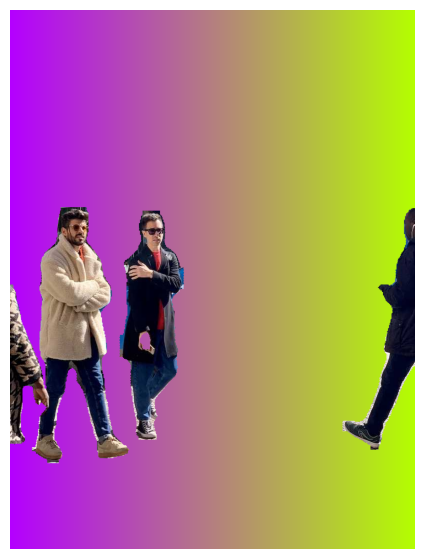

In [12]:
# 간단한 그라데이션 배경을 만들고, 선택한 객체만 원본에서 가져옵니다.
x = np.linspace(0, 255, w, dtype=np.uint8)
bg = np.tile(x, (h, 1))
bg = cv2.merge([255 - bg, bg, np.full_like(bg, 180)])

composite = bg.copy()
composite[mask] = img[mask]

show(composite)

## 2.7.자동 모자이크
- 선택한 객체 영역만 흐리게 처리한다.
- 사람 얼굴 전체가 아니라 사람 mask 전체에 적용된다.

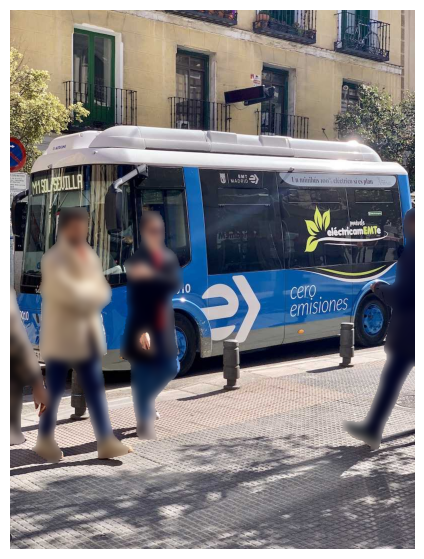

In [13]:
# 선택한 객체 영역에만 블러를 적용해 자동 모자이크를 만듭니다.
blur = cv2.GaussianBlur(img, (51, 51), 0) # (51, 51) : 블러 커널 크기, 클수록 더 강하게 흐려짐.
mosaic = img.copy()
mosaic[mask] = blur[mask]

show(mosaic)

# 연습문제

1. `TARGET = 'bus'`로 바꿔서 버스만 컬러로 남겨보기
2. `conf=0.5`로 바꿔서 예측 개수가 어떻게 달라지는지 확인하기
4. 본인 이미지 파일을 업로드한 뒤 세그멘테이션 후 다양한 Task 수행해보기


In [15]:
# 원하는 객체 클래스 이름 지정. 예: person, bus, car, bicycle
TARGET = ['bus']
h, w = img.shape[:2]

# 모델이 예측한 mask와 클래스 이름을 꺼냅니다.
masks = result.masks.data.cpu().numpy()
classes = [seg_model.names[int(i)] for i in result.boxes.cls.cpu()]
binary = [cv2.resize(m, (w, h)) > 0.5 for m in masks]

# TARGET 클래스가 여러 개면 하나의 mask로 합칩니다.
selected = [m for m, name in zip(binary, classes) if name in TARGET]
if selected:
    mask = np.any(selected, axis=0)
    print(f'선택 클래스: {TARGET}, 객체 수: {len(selected)}')
else:
    # TARGET이 없으면 confidence가 가장 높은 객체 하나를 대신 선택합니다.
    idx = int(result.boxes.conf.argmax().item())
    mask = binary[idx]
    print(f'{TARGET} 없음 -> 선택 클래스: {classes[idx]}')

선택 클래스: ['bus'], 객체 수: 1


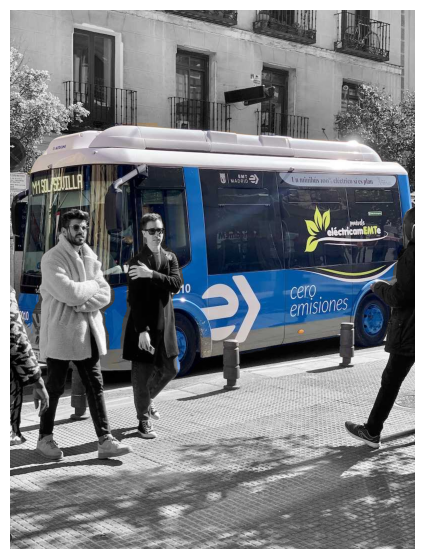

In [18]:
# 배경은 흑백으로 바꾸고 선택한 객체만 컬러로 유지합니다.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
colorpop = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
colorpop[mask] = img[mask]

show(colorpop)